# Assignment 3: Text Generation, Prompting, and LLM Agents

**COMP3361: Natural Language Processing - University of Hong Kong, Spring 2026**

In this assignment, you will:
1. Implement decoding algorithms for text generation (30%)
2. Explore prompting strategies for math reasoning (25%)
3. Build a ReAct agent from scratch with tool use (35%)
4. Bonus: Improve agent performance (Extra 10%)

**Submission**: Clear all outputs, rerun all cells, and submit as `UNIVERSITYNUMBER.ipynb`.

---
## Section 1: Decoding Algorithms (30%)

In [ ]:
!pip install -q vllm transformers datasets evaluate

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [3]:
"""Set device and random seeds"""

######################################################
#  The following helper code is given to you.
######################################################

from tqdm import tqdm
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {device}')

def set_seed(seed=19260817):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

device: cuda


In [4]:
from datasets import load_dataset

dataset = load_dataset('igormorgado/ROCStories2016')
train_data, dev_data, test_data = dataset['train'], dataset['validation'], dataset['test']

# Construct 'prompt' field from sentence1 for story generation
def add_prompt(example):
    example['prompt'] = example['sentence1']
    return example

train_data = train_data.map(add_prompt)
dev_data = dev_data.map(add_prompt)
test_data = test_data.map(add_prompt)

print(train_data[0])

README.md: 0.00B [00:00, ?B/s]

c:\Users\livea\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\livea\.cache\huggingface\hub\datasets--igormorgado--ROCStories2016. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/train-00000-of-00001.parquet:   0%|          | 0.00/10.1M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/435k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/435k [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/1871 [00:00<?, ? examples/s]

Map:   0%|          | 0/45496 [00:00<?, ? examples/s]

Map:   0%|          | 0/1871 [00:00<?, ? examples/s]

Map:   0%|          | 0/1871 [00:00<?, ? examples/s]

{'storyid': '9a51198e-96f1-42c3-b09d-a3e1e067d803', 'storytitle': 'Overweight Kid', 'sentence1': "Dan's parents were overweight.", 'sentence2': 'Dan was overweight as well.', 'sentence3': 'The doctors told his parents it was unhealthy.', 'sentence4': 'His parents understood and decided to make a change.', 'sentence5': 'They got themselves and Dan on a diet.', 'sentenceE': '', 'prompt': "Dan's parents were overweight."}


In [5]:
"""Prepare evaluation metrics"""

######################################################
#  The following helper code is given to you.
######################################################

from transformers import RobertaForSequenceClassification, RobertaTokenizer

cola_model_name = "textattack/roberta-base-CoLA"
cola_tokenizer = RobertaTokenizer.from_pretrained(cola_model_name)
cola_model = RobertaForSequenceClassification.from_pretrained(cola_model_name).to(device)

def batchify(data, batch_size):
    assert batch_size > 0
    for i in range(0, len(data), batch_size):
        yield data[i:i+batch_size]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

c:\Users\livea\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\livea\.cache\huggingface\hub\models--textattack--roberta-base-CoLA. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: textattack/roberta-base-CoLA
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
"""Evaluation functions"""

######################################################
#  The following helper code is given to you.
######################################################

from transformers import GPT2LMHeadModel, GPT2TokenizerFast

_ppl_tokenizer = GPT2TokenizerFast.from_pretrained('gpt2')
_ppl_model = GPT2LMHeadModel.from_pretrained('gpt2').to(device)
_ppl_model.eval()

def compute_perplexity(texts, batch_size=4, max_length=512):
    """Compute mean perplexity of a list of texts using GPT-2."""
    nlls = []
    for text in texts:
        if not text.strip():
            continue
        encodings = _ppl_tokenizer(text, return_tensors='pt', truncation=True, max_length=max_length).to(device)
        input_ids = encodings.input_ids
        if input_ids.shape[1] < 2:
            continue
        with torch.no_grad():
            outputs = _ppl_model(input_ids, labels=input_ids)
        nll = outputs.loss.item()
        nlls.append(nll)
    if not nlls:
        return float('inf')
    import math
    return math.exp(sum(nlls) / len(nlls))


def compute_fluency(texts, batch_size=8):
    scores = []
    for b_texts in batchify(texts, batch_size):
        inputs = cola_tokenizer(b_texts, padding=True, truncation=True, return_tensors="pt").to(device)
        with torch.no_grad():
            logits = cola_model(**inputs).logits
        predictions = torch.argmax(logits, dim=-1)
        scores.extend(predictions.cpu().tolist())
    return sum(scores) / len(scores)


def compute_diversity(texts, n=3):
    all_ngrams = []
    for text in texts:
        tokens = text.split()
        ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
        all_ngrams.extend(ngrams)
    if len(all_ngrams) == 0:
        return 0
    return len(set(all_ngrams)) / len(all_ngrams)


def compute_repetition(texts, n=4):
    total = 0
    repeated = 0
    for text in texts:
        tokens = text.split()
        ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
        total += len(ngrams)
        repeated += len(ngrams) - len(set(ngrams))
    if total == 0:
        return 0
    return repeated / total

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

c:\Users\livea\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\livea\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [7]:
"""Load model and tokenizer"""

######################################################
#  The following helper code is given to you.
######################################################

from transformers import GPT2LMHeadModel, GPT2Tokenizer

model_name = 'gpt2'
tokenizer = GPT2Tokenizer.from_pretrained(model_name, pad_token="<|endoftext|>")
model = GPT2LMHeadModel.from_pretrained(model_name).to(device)
model.eval()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [8]:
def decode(prompts, max_len, method, **kwargs):
    encodings_dict = tokenizer(prompts, return_tensors="pt", padding=True)
    input_ids = encodings_dict['input_ids'].to(device)
    attention_mask = encodings_dict['attention_mask'].to(device)

    batch_size, input_seq_len = input_ids.shape
    unfinished_sequences = torch.ones(batch_size, dtype=torch.long, device=device)
    eos_token_id_tensor = torch.tensor([tokenizer.eos_token_id]).to(device)

    for step in range(max_len):
        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        next_token_logits = outputs.logits[:, -1, :]
        next_tokens = method(next_token_logits, **kwargs)
        next_tokens = next_tokens * unfinished_sequences + tokenizer.pad_token_id * (1 - unfinished_sequences)

        input_ids = torch.cat([input_ids, next_tokens[:, None]], dim=-1)
        attention_mask = torch.cat(
            [attention_mask, torch.ones((batch_size, 1), dtype=torch.long, device=device)], dim=-1
        )
        unfinished_sequences = unfinished_sequences.mul(
            next_tokens.tile(eos_token_id_tensor.shape[0], 1).ne(eos_token_id_tensor.unsqueeze(1)).prod(dim=0)
        )
        if unfinished_sequences.max() == 0:
            break

    decoded = tokenizer.batch_decode(input_ids[:, input_seq_len:], skip_special_tokens=True)
    return decoded

In [9]:
"""Debug helper"""

######################################################
#  The following helper code is given to you.
######################################################

dev_prompt = dev_data[0]['prompt']
print(f'Dev prompt: {dev_prompt}')
print()

def show_generations(method_name, method, n=3, max_len=100, **kwargs):
    """Generate n continuations from the dev prompt and display them."""
    for i in range(n):
        output = decode([dev_prompt], max_len, method, **kwargs)
        print(f'[{i+1}] {output[0][:200]}')
    print()

Dev prompt: Rick grew up in a troubled household.



### 1.1 Greedy Decoding

Select the next token as the one with the highest logit. Implement the `greedy()` function.

- Input: `next_token_logits` - Tensor of shape `(B, V)` (batch size x vocabulary size)
- Output: `next_tokens` - LongTensor of shape `(B,)`

In [10]:
def greedy(next_token_logits):
    '''
    inputs:
    - next_token_logits: Tensor(size = (B, V), dtype = float)
    outputs:
    - next_tokens: Tensor(size = (B,), dtype = long)
    '''
    # TODO: Implement greedy decoding
    next_tokens = torch.argmax(next_token_logits, dim=-1)
    return next_tokens

show_generations('Greedy', greedy)

[1]  He was a high school dropout, and he was a high school dropout. He was a high school dropout. He was a high school dropout. He was a high school dropout. He was a high school dropout. He was a high s
[2]  He was a high school dropout, and he was a high school dropout. He was a high school dropout. He was a high school dropout. He was a high school dropout. He was a high school dropout. He was a high s
[3]  He was a high school dropout, and he was a high school dropout. He was a high school dropout. He was a high school dropout. He was a high school dropout. He was a high school dropout. He was a high s



### 1.2 Vanilla Sampling and Temperature Sampling

**Vanilla sampling**: Sample the next token from the probability distribution defined by softmax over logits.

**Temperature sampling**: Divide logits by temperature `t` before applying softmax. Implement both `sample()` and `temperature()` functions.

- For testing, we use `t = 0.8`, but your implementation should support arbitrary `t > 0`.

In [11]:
def sample(next_token_logits):
    '''
    inputs:
    - next_token_logits: Tensor(size = (B, V), dtype = float)
    outputs:
    - next_tokens: Tensor(size = (B,), dtype = long)
    Hint: use torch.multinomial()
    '''
    # TODO: Implement vanilla sampling
    probs = F.softmax(next_token_logits, dim=-1)
    next_tokens = torch.multinomial(probs, num_samples=1).squeeze(-1)
    return next_tokens

show_generations('Vanilla Sampling', sample)

[1]  He writes about his mother's journey from gentrification to wealth, (1982), the rise of gambling, and how his brother, Sam, stepped into the Mormon Way. He teaches political science at the University
[2]  Most of his six brothers were killed in misguided attacks. My parents were both professors in a liberal arts school. After graduation, he marched in Bloomsbury, Connecticut, for a leaflet that promis
[3]  His father avoided the branches of society because he hated being home. His mother encouraged him to live alone and glass was the ship. It is possibly because he had the ambition to take up a religio



In [12]:
def temperature(next_token_logits, t):
    '''
    inputs:
    - next_token_logits: Tensor(size = (B, V), dtype = float)
    - t: float, temperature parameter (t > 0)
    outputs:
    - next_tokens: Tensor(size = (B,), dtype = long)
    '''
    # TODO: Implement temperature sampling
    scaled_logits = next_token_logits / t
    probs = F.softmax(scaled_logits, dim=-1)
    next_tokens = torch.multinomial(probs, num_samples=1).squeeze(-1)
    return next_tokens

show_generations('Temperature (t=0.8)', temperature, t=0.8)

[1]  Grievous narratives are a thing of the past. And in his sketch comedy fare, he proved the potential of the sketch comedy genre by making it his own.
[2]  His parents divorced in 1977, and he went on to attend Tolhurst College, where his father studied as a student anthropologist. He studied urology at Columbia University, where he also worked as an as
[3]  He understood his family was in danger and as a result, he rallied Muslim American men to help him.

After a teenage high school graduation, he followed his father in the military and enrolled at Uni



### 1.3 Top-k Sampling

Sample from only the top-k highest-probability tokens. The sampling probability should be proportional to the original logits, renormalized to sum to 1.

- For testing, we use `k = 20`, but your implementation should support arbitrary `k`.

In [13]:
def topk(next_token_logits, k):
    '''
    inputs:
    - next_token_logits: Tensor(size = (B, V), dtype = float)
    - k: int, number of top tokens to consider
    outputs:
    - next_tokens: Tensor(size = (B,), dtype = long)
    '''
    # TODO: Implement top-k sampling
    top_k_logits, top_k_indices = torch.topk(next_token_logits, k, dim=-1)
    probs = F.softmax(top_k_logits, dim=-1)
    sampled_indices = torch.multinomial(probs, num_samples=1).squeeze(-1)
    next_tokens = top_k_indices.gather(-1, sampled_indices.unsqueeze(-1)).squeeze(-1)
    return next_tokens

show_generations('Top-k (k=20)', topk, k=20)

[1]  But she had a vision of her future with her parents and her siblings, and she has been the center of her life for nearly 30 years—her daughter being born in August, 2013, and two other siblings in Ju
[2]  She says she was bullied, harassed and abused.

"I never saw my dad or my sisters. I never heard about anything," she said. "And I never knew the things he's had to go through."

Her mom and stepfath
[3]  His grandfather was an ex-con. When he was 15, he left his parents to find a job selling cars and then worked in the real estate industry. Then, during college, he moved to the New York area to work 



### 1.4 Top-p (Nucleus) Sampling

Sample from the smallest set of tokens whose cumulative probability exceeds threshold `p`.

- For testing, we use `p = 0.7`, but your implementation should support arbitrary `p`.

In [14]:
def topp(next_token_logits, p):
    '''
    inputs:
    - next_token_logits: Tensor(size = (B, V), dtype = float)
    - p: float, cumulative probability threshold (0 <= p <= 1)
    outputs:
    - next_tokens: Tensor(size = (B,), dtype = long)
    '''
    # TODO: Implement top-p (nucleus) sampling
    sorted_logits, sorted_indices = torch.sort(next_token_logits, descending=True, dim=-1)
    sorted_probs = F.softmax(sorted_logits, dim=-1)
    cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

    # Remove tokens with cumulative probability above the threshold
    # Shift right so the first token exceeding p is kept
    sorted_indices_to_remove = cumulative_probs - sorted_probs > p
    sorted_logits[sorted_indices_to_remove] = float('-inf')

    # Sample from the filtered distribution
    probs = F.softmax(sorted_logits, dim=-1)
    sampled_indices = torch.multinomial(probs, num_samples=1).squeeze(-1)
    next_tokens = sorted_indices.gather(-1, sampled_indices.unsqueeze(-1)).squeeze(-1)
    return next_tokens

show_generations('Top-p (p=0.7)', topp, p=0.7)

[1]  He remembers being targeted by the Los Angeles Police Department for his politics. He had been part of the Catholic Church's anti-war movement and he was kicked out of a Catholic church. "They sent m
[2]  She began her own musical career with her son, Brian, and his friends.

"I never would have expected it to happen," said Mick. "My family was always there to support me. And when my brother came home
[3]  He's been in rehab for a while now and has some other issues. He says he's done a lot of things that could have gone wrong, like making his parents and sister leave. He says he knows that it's possib



### 1.5 Evaluation and Analysis

Run the evaluation cell below, then complete the analysis tasks.

In [15]:
"""Evaluation"""

######################################################
#  The following helper code is given to you.
######################################################

prompts = [item['prompt'] for item in test_data][:5]
GENERATIONS_PER_PROMPT = 5
MAX_LEN = 100

methods = {
    'greedy': {'method': greedy},
    'sample': {'method': sample},
    'temperature_0.8': {'method': temperature, 't': 0.8},
    'topk_20': {'method': topk, 'k': 20},
    'topp_0.7': {'method': topp, 'p': 0.7},
}

results = {}
for name, config in methods.items():
    all_texts = []
    for prompt in tqdm(prompts, desc=name):
        for _ in range(GENERATIONS_PER_PROMPT):
            texts = decode([prompt], MAX_LEN, **config)
            all_texts.extend(texts)
    
    ppl = compute_perplexity(all_texts)
    flu = compute_fluency(all_texts)
    div = compute_diversity(all_texts)
    rep = compute_repetition(all_texts)
    results[name] = {'perplexity': ppl, 'fluency': flu, 'diversity': div, 'repetition': rep}
    print(f'{name}: PPL={ppl:.2f}, Fluency={flu:.4f}, Diversity={div:.4f}, Repetition={rep:.4f}')

greedy: 100%|██████████| 5/5 [00:18<00:00,  3.62s/it]
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


greedy: PPL=1.92, Fluency=1.0000, Diversity=0.0449, Repetition=0.7545


sample: 100%|██████████| 5/5 [00:17<00:00,  3.59s/it]


sample: PPL=43.67, Fluency=0.2400, Diversity=0.9984, Repetition=0.0000


temperature_0.8: 100%|██████████| 5/5 [00:18<00:00,  3.67s/it]


temperature_0.8: PPL=13.87, Fluency=0.6800, Diversity=0.9792, Repetition=0.0034


topk_20: 100%|██████████| 5/5 [00:18<00:00,  3.63s/it]


topk_20: PPL=11.41, Fluency=0.8800, Diversity=0.9744, Repetition=0.0054


topp_0.7: 100%|██████████| 5/5 [00:19<00:00,  3.83s/it]


topp_0.7: PPL=10.52, Fluency=0.9200, Diversity=0.9676, Repetition=0.0070


### 1.6 Temperature Sweep Analysis

Run temperature sampling with `t` values `[0.3, 0.5, 0.8, 1.0, 1.5]`. For each value, compute perplexity, diversity, and repetition rate. **Plot curves** showing how each metric changes with temperature.

Use 3 test prompts with 5 generations each.

t=0.3: 100%|██████████| 3/3 [00:11<00:00,  3.70s/it]


t=0.3: PPL=1.86, Diversity=0.2023, Repetition=0.7588


t=0.5: 100%|██████████| 3/3 [00:11<00:00,  3.72s/it]


t=0.5: PPL=4.16, Diversity=0.6625, Repetition=0.2726


t=0.8: 100%|██████████| 3/3 [00:13<00:00,  4.42s/it]


t=0.8: PPL=13.41, Diversity=0.9754, Repetition=0.0098


t=1.0: 100%|██████████| 3/3 [00:25<00:00,  8.37s/it]


t=1.0: PPL=53.08, Diversity=0.9990, Repetition=0.0000


t=1.5: 100%|██████████| 3/3 [00:15<00:00,  5.25s/it]


t=1.5: PPL=13838.22, Diversity=1.0000, Repetition=0.0000


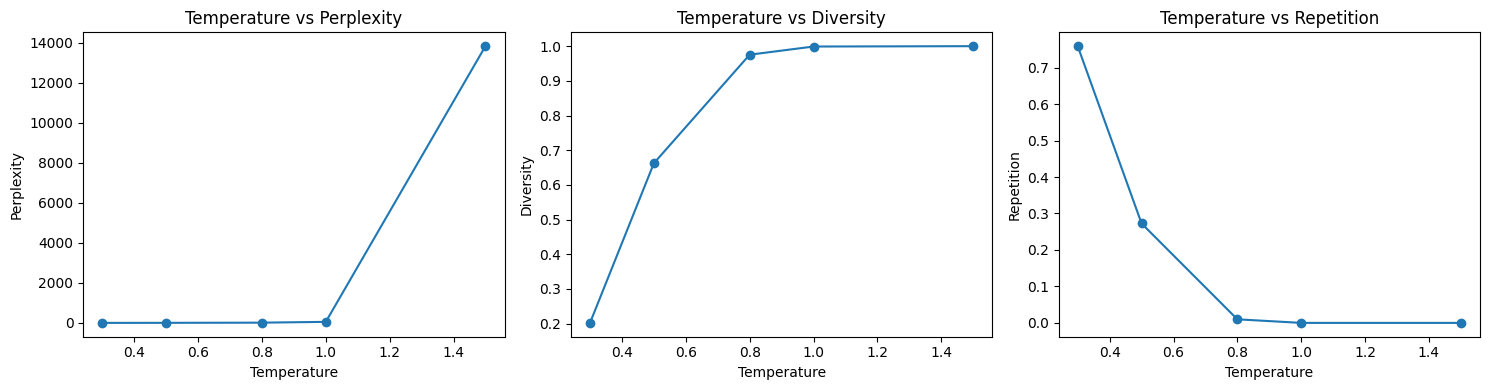

In [16]:
# TODO: Run temperature sweep and plot the curves
temperatures = [0.3, 0.5, 0.8, 1.0, 1.5]
sweep_prompts = [item['prompt'] for item in test_data][:3]
SWEEP_GENS = 5

sweep_ppls, sweep_divs, sweep_reps = [], [], []

for t in temperatures:
    all_texts = []
    for prompt in tqdm(sweep_prompts, desc=f"t={t}"):
        for _ in range(SWEEP_GENS):
            texts = decode([prompt], MAX_LEN, temperature, t=t)
            all_texts.extend(texts)
    ppl = compute_perplexity(all_texts)
    div = compute_diversity(all_texts)
    rep = compute_repetition(all_texts)
    sweep_ppls.append(ppl)
    sweep_divs.append(div)
    sweep_reps.append(rep)
    print(f"t={t}: PPL={ppl:.2f}, Diversity={div:.4f}, Repetition={rep:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(temperatures, sweep_ppls, marker='o')
axes[0].set_xlabel('Temperature')
axes[0].set_ylabel('Perplexity')
axes[0].set_title('Temperature vs Perplexity')

axes[1].plot(temperatures, sweep_divs, marker='o')
axes[1].set_xlabel('Temperature')
axes[1].set_ylabel('Diversity')
axes[1].set_title('Temperature vs Diversity')

axes[2].plot(temperatures, sweep_reps, marker='o')
axes[2].set_xlabel('Temperature')
axes[2].set_ylabel('Repetition')
axes[2].set_title('Temperature vs Repetition')

plt.tight_layout()
plt.show()

### Discussion Questions (10%)

Answer the following questions based on your experiments.

**Q1.1**: Compare the outputs of greedy decoding and vanilla sampling. 
What differences do you observe? What are the strengths and weaknesses of each?

*Your answer:*

**Q1.2**: From your temperature sweep plots, describe the relationship between temperature and each metric (perplexity, diversity, repetition). What is the trade-off?

*Your answer:*

**Q1.3**: Report the evaluation metrics (perplexity, fluency, diversity, repetition) of all 6 methods in a table. Which method achieves the best balance across all metrics? Justify your choice.

*Your answer:*

**Q1.4**: Looking at the repetition rates in your evaluation table, 
which method has the highest repetition? Explain why this method tends to produce repetitive text.

*Your answer:*

---
## Section 2: Prompting Strategies for Math Reasoning (25%)

In [19]:
import os
# Use default HF cache (~/.cache/huggingface) - no need to override
# os.environ["HF_HOME"] = "..."

from vllm import LLM, SamplingParams
model_id = "Qwen/Qwen2.5-7B-Instruct-GPTQ-Int4"
llm = LLM(model=model_id, enforce_eager=True)

ModuleNotFoundError: No module named 'vllm._C'

In [ ]:
######################################################
#  The following helper code is given to you.
######################################################

from openai import OpenAI
from transformers import AutoTokenizer

class VLLMClient:
    def __init__(self, model_id, **kwargs):
        self.model_id = model_id

    def __call__(self, prompt: str, **kwargs):
        response = llm.generate(
            prompts=prompt,
            sampling_params=SamplingParams(
                temperature=kwargs.get("temperature", 0.2),
                max_tokens=kwargs.get("max_tokens", 256),
            )
        )
        return response[0].outputs[0].text

model_llm = VLLMClient(model_id)
model_llm("San Francisco is a", max_tokens=42)

In [ ]:
######################################################
#  The following helper code is given to you.
######################################################

ARC_EXAMPLARS = [
    {
        "question": "A ball is thrown straight up into the air. At the highest point, the ball's velocity is",
        "choices": ["zero", "at its maximum", "equal to the initial velocity", "negative"],
        "cot_answer": "When a ball is thrown straight up, it decelerates due to gravity. At the highest point, the ball momentarily stops before falling back down. Therefore, the velocity at the highest point is zero. The answer is 0.",
        "short_answer": "0"
    },
    {
        "question": "Which of the following is the best example of a chemical change?",
        "choices": ["crushing a rock", "melting butter", "burning wood", "dissolving sugar in water"],
        "cot_answer": "Crushing a rock, melting butter, and dissolving sugar are physical changes because the substance's chemical composition doesn't change. Burning wood is a chemical change because it produces new substances (ash, carbon dioxide, water vapor). The answer is 2.",
        "short_answer": "2"
    },
    {
        "question": "A student wants to determine how the mass of an object affects the force needed to move it. Which tool should the student use to measure mass?",
        "choices": ["ruler", "balance", "thermometer", "graduated cylinder"],
        "cot_answer": "A ruler measures length, a thermometer measures temperature, and a graduated cylinder measures volume. A balance is used to measure mass by comparing the unknown mass to known masses. The answer is 1.",
        "short_answer": "1"
    },
    {
        "question": "Earth's core is primarily made up of which of the following materials?",
        "choices": ["ite andite", "ite and silica", "iron and nickel", "ite andite"],
        "cot_answer": "Scientists have determined through seismic studies and analysis of meteorites that Earth's core is primarily composed of iron and nickel. These heavy elements sank to the center during Earth's formation. The answer is 2.",
        "short_answer": "2"
    },
    {
        "question": "Which of these is a function of the skeletal system?",
        "choices": ["to transport oxygen", "to protect organs", "to digest food", "to regulate body temperature"],
        "cot_answer": "Transporting oxygen is the circulatory system's function, digesting food is the digestive system's, and regulating body temperature involves the integumentary and circulatory systems. Protecting organs (like the brain by the skull, heart by the ribcage) is a key function of the skeletal system. The answer is 1.",
        "short_answer": "1"
    },
    {
        "question": "What happens to the resistance in a wire as the temperature increases?",
        "choices": ["resistance decreases", "resistance increases", "resistance stays the same", "resistance becomes zero"],
        "cot_answer": "In most conductors (like metals), increasing temperature causes atoms to vibrate more, which increases collisions with electrons flowing through the wire. This increased collision rate means higher resistance. The answer is 1.",
        "short_answer": "1"
    },
    {
        "question": "A plant wilts when it does not receive enough",
        "choices": ["carbon dioxide", "water", "oxygen", "nitrogen"],
        "cot_answer": "Wilting occurs when plant cells lose turgor pressure due to water loss. While plants need carbon dioxide for photosynthesis, oxygen for respiration, and nitrogen for growth, it is the lack of water that directly causes wilting by reducing turgor pressure in cells. The answer is 1.",
        "short_answer": "1"
    },
    {
        "question": "Which of these would be the most effective way to reduce the amount of fossil fuel used for transportation?",
        "choices": ["build wider roads", "use public transportation", "increase parking spaces", "lower speed limits"],
        "cot_answer": "Building wider roads and increasing parking spaces would likely encourage more driving, thus more fossil fuel use. Lowering speed limits has a minor effect. Public transportation is the most effective because one bus or train replaces many individual cars, significantly reducing per-person fossil fuel consumption. The answer is 1.",
        "short_answer": "1"
    }
]

In [ ]:
######################################################
#  The following helper code is given to you.
######################################################

!mkdir -p data
# Download ARC-Challenge test set (first 50 examples)
from datasets import load_dataset
import json

arc_dataset = load_dataset("allenai/ai2_arc", "ARC-Challenge", split="test")
arc_data = []
for item in list(arc_dataset)[:50]:
    choices = item['choices']['text']
    labels = item['choices']['label']
    answer_key = item['answerKey']
    # Convert letter answer to index
    answer_idx = labels.index(answer_key) if answer_key in labels else ord(answer_key) - ord('A')
    arc_data.append({
        "question": item['question'],
        "choices": choices,
        "true_answer": str(answer_idx),
        "source": "ARC"
    })

with open("data/arc.jsonl", "w") as f:
    for item in arc_data:
        f.write(json.dumps(item) + "\n")

print(f"Loaded {len(arc_data)} ARC-Challenge questions")
print(json.dumps(arc_data[0], indent=2))

In [ ]:
######################################################
#  The following helper code is given to you.
######################################################

import json

def load_eval_data(task):
    with open(f"data/{task}.jsonl", "r") as f:
        return [json.loads(line) for line in f]

print("Example ARC question:")
print(json.dumps(load_eval_data("arc")[0], indent=4))

In [ ]:
######################################################
#  The following helper code is given to you.
######################################################

import os
import json
import datetime
from pathlib import Path
from tqdm import tqdm

def answer_questions(task, agent, action_type, answers_file):
    """Run agent on all questions in a task and save answers."""
    data = load_eval_data(task)
    Path("output").mkdir(exist_ok=True)
    
    existing = set()
    if os.path.exists(answers_file):
        with open(answers_file, "r") as f:
            for line in f:
                item = json.loads(line)
                existing.add(item["question"])
    
    for item in tqdm(data, desc=f"Running {action_type} on {task}"):
        q = item["question"]
        if isinstance(item.get("choices"), list):
            choices_str = "\n".join(f"  {i}. {c}" for i, c in enumerate(item["choices"]))
            q = f"{q}\nChoices:\n{choices_str}\nAnswer with only the choice number (0, 1, 2, ...)."
        if q in existing:
            continue
        try:
            answer = agent.run(q)
        except Exception as e:
            answer = f"ERROR: {e}"
        
        result = {
            "question": item["question"],
            "answer": answer,
            "true_answer": item["true_answer"],
            "source": item["source"],
            "model_id": model_llm.model_id,
            "agent_action_type": action_type,
            "timestamp": str(datetime.datetime.now())
        }
        with open(answers_file, "a") as f:
            f.write(json.dumps(result) + "\n")

### 2.1 Few-shot Direct Prompting

Implement `build_input()` in `FewShotReasoner` to construct an 8-shot prompt using ARC exemplars.

The prompt format should be:
```
Answer the following questions. Choose the correct option by its number.

Question: {question1}
Choices:
  0. {choice0}
  1. {choice1}
  ...
Answer: {answer_index1}

Question: {question2}
...

Question: {inference_question}
Choices:
  0. {choice0}
  ...
Answer:
```

In [ ]:
from eval_utils import score_answers

class FewShotReasoner:
    def __init__(self, model, n_shots):
        self.model = model
        self.n_shots = n_shots

    def build_input(self, question):
        """Build an n-shot direct prompt using ARC_EXAMPLARS."""
        # TODO: Implement this
        prompt = "Answer the following questions. Choose the correct option by its number.\n\n"
        for ex in ARC_EXAMPLARS[:self.n_shots]:
            choices_str = "\n".join(f"  {i}. {c}" for i, c in enumerate(ex["choices"]))
            prompt += f"Question: {ex['question']}\nChoices:\n{choices_str}\nAnswer: {ex['short_answer']}\n\n"
        # Parse the inference question (may already have choices appended by answer_questions)
        if "\nChoices:\n" in question:
            parts = question.split("\nChoices:\n")
            q_text = parts[0]
            rest = parts[1]
            # Strip the trailing instruction line
            choice_lines = []
            for line in rest.strip().split("\n"):
                if line.startswith("  ") and line.strip()[0].isdigit():
                    choice_lines.append(line)
            prompt += f"Question: {q_text}\nChoices:\n" + "\n".join(choice_lines) + "\nAnswer:"
        else:
            prompt += f"Question: {question}\nAnswer:"
        return prompt

    def run(self, question):
        prompt = self.build_input(question)
        return self.model(prompt=prompt, max_tokens=32, temperature=0.0)


def run_arc_fewshot(task="arc", action_type="fewshot"):
    answers_file = f"output/{model_id.replace('/', '__')}__{action_type}__{task}.jsonl"
    reasoner = FewShotReasoner(model_llm, 8)
    answer_questions(task, reasoner, action_type, answers_file)
    df = score_answers([answers_file])
    print(df)

run_arc_fewshot()

### 2.2 Few-shot Chain-of-Thought Prompting

Implement `FewShotCoTReasoner` using chain-of-thought prompting. Use the `cot_answer` field from `ARC_EXAMPLARS`.

The prompt format should include the reasoning steps in the examples, and the model should generate reasoning before the final answer.

In [ ]:
import re

class FewShotCoTReasoner:
    def __init__(self, model, n_shots):
        self.model = model
        self.n_shots = n_shots

    def build_input(self, question):
        """Build an n-shot chain-of-thought prompt using ARC_EXAMPLARS."""
        # TODO: Implement this
        prompt = "Answer the following questions. Choose the correct option by its number. Think step by step.\n\n"
        for ex in ARC_EXAMPLARS[:self.n_shots]:
            choices_str = "\n".join(f"  {i}. {c}" for i, c in enumerate(ex["choices"]))
            prompt += f"Question: {ex['question']}\nChoices:\n{choices_str}\nAnswer: {ex['cot_answer']}\n\n"
        # Parse the inference question
        if "\nChoices:\n" in question:
            parts = question.split("\nChoices:\n")
            q_text = parts[0]
            rest = parts[1]
            choice_lines = []
            for line in rest.strip().split("\n"):
                if line.startswith("  ") and line.strip()[0].isdigit():
                    choice_lines.append(line)
            prompt += f"Question: {q_text}\nChoices:\n" + "\n".join(choice_lines) + "\nAnswer:"
        else:
            prompt += f"Question: {question}\nAnswer:"
        return prompt

    def extract_answer(self, response):
        """Extract the final numeric answer from CoT response."""
        # TODO: Extract the answer number from the response
        # Look for 'The answer is X' pattern first
        match = re.search(r'[Tt]he answer is (\d+)', response)
        if match:
            return match.group(1)
        # Fall back to last number in the response
        numbers = re.findall(r'\d+', response)
        if numbers:
            return numbers[-1]
        return response.strip()

    def run(self, question):
        prompt = self.build_input(question)
        response = self.model(prompt=prompt, max_tokens=512, temperature=0.0)
        return self.extract_answer(response)


def run_arc_fewshot_cot(task="arc", action_type="fewshot_cot"):
    answers_file = f"output/{model_id.replace('/', '__')}__{action_type}__{task}.jsonl"
    reasoner = FewShotCoTReasoner(model_llm, 8)
    answer_questions(task, reasoner, action_type, answers_file)
    df = score_answers([answers_file])
    print(df)

run_arc_fewshot_cot()

### Section 2 Discussion

**Q2.1**: Report the accuracy of Few-shot Direct vs Few-shot CoT in a table. Discuss which method performs better and why.

*Your answer:*

**Q2.2**: Why does Chain-of-Thought prompting help on reasoning tasks compared to direct prompting? 
When might CoT not help, or even hurt performance?

*Your answer:*

---
## Section 3: Building a ReAct Agent from Scratch (35%)

In this section, you will build a **ReAct** (Reasoning + Acting) agent that interleaves thinking and tool use to solve diverse tasks.

You will evaluate on two datasets:
- **MATH**: Math problems requiring precise calculation and reasoning
- **GAIA**: Complex research-oriented tasks requiring multiple capabilities (knowledge retrieval, calculation, and synthesis)

Unlike Section 2 which relied on the model's internal knowledge, here you will implement the full ReAct loop using **text generation only** - the model outputs structured text that you parse to determine tool calls.

### ReAct Format
```
Thought: I need to find the population of France.
Action: wiki_search
Action Input: population of France
Observation: France has a population of approximately 67.9 million...
Thought: Now I need to multiply by 3.
Action: calculator
Action Input: 67900000 * 3
Observation: 203700000
Thought: I have the answer.
Action: finish
Action Input: 203700000
```

### 3.1 Implement Tools

Implement two tools that the agent will use.

In [ ]:
!pip install -q wikipedia

In [ ]:
import wikipedia

class WikiSearchTool:
    """Search Wikipedia and return a summary."""
    name = "wiki_search"
    description = "Search Wikipedia for a topic and return a summary. Input should be a search query string."

    def __call__(self, query: str) -> str:
        """Search Wikipedia and return the summary of the top result.
        Handle disambiguation and page not found errors gracefully."""
        try:
            results = wikipedia.search(query, results=3)
            if not results:
                return f"No Wikipedia results found for '{query}'."
            try:
                summary = wikipedia.summary(results[0], sentences=5)
                return summary
            except wikipedia.exceptions.DisambiguationError as e:
                # Pick the first option from disambiguation
                try:
                    summary = wikipedia.summary(e.options[0], sentences=5)
                    return summary
                except Exception:
                    return f"Disambiguation: multiple results for '{query}'. Options: {e.options[:5]}"
            except wikipedia.exceptions.PageError:
                return f"Wikipedia page not found for '{results[0]}'."
        except Exception as e:
            return f"Error searching Wikipedia: {str(e)}"


# Test
wiki_tool = WikiSearchTool()
print(wiki_tool("Eiffel Tower")[:500])

In [ ]:
import ast
import math
import operator

class CalculatorTool:
    """Evaluate a mathematical expression."""
    name = "calculator"
    description = "Evaluate a mathematical expression. Input should be a valid Python math expression as a string."

    # Allowed operators and functions
    ALLOWED_OPS = {
        ast.Add: operator.add,
        ast.Sub: operator.sub,
        ast.Mult: operator.mul,
        ast.Div: operator.truediv,
        ast.FloorDiv: operator.floordiv,
        ast.Mod: operator.mod,
        ast.Pow: operator.pow,
        ast.USub: operator.neg,
        ast.UAdd: operator.pos,
    }
    ALLOWED_FUNCS = {
        'abs': abs, 'round': round, 'min': min, 'max': max,
        'sqrt': math.sqrt, 'log': math.log, 'log10': math.log10,
        'sin': math.sin, 'cos': math.cos, 'tan': math.tan,
        'pi': math.pi, 'e': math.e, 'factorial': math.factorial,
        'ceil': math.ceil, 'floor': math.floor, 'pow': pow,
    }

    def _eval_node(self, node):
        if isinstance(node, ast.Expression):
            return self._eval_node(node.body)
        elif isinstance(node, ast.Constant):
            if isinstance(node.value, (int, float, complex)):
                return node.value
            raise ValueError(f"Unsupported constant: {node.value}")
        elif isinstance(node, ast.BinOp):
            op_type = type(node.op)
            if op_type not in self.ALLOWED_OPS:
                raise ValueError(f"Unsupported operator: {op_type.__name__}")
            left = self._eval_node(node.left)
            right = self._eval_node(node.right)
            return self.ALLOWED_OPS[op_type](left, right)
        elif isinstance(node, ast.UnaryOp):
            op_type = type(node.op)
            if op_type not in self.ALLOWED_OPS:
                raise ValueError(f"Unsupported unary operator: {op_type.__name__}")
            operand = self._eval_node(node.operand)
            return self.ALLOWED_OPS[op_type](operand)
        elif isinstance(node, ast.Call):
            if isinstance(node.func, ast.Name) and node.func.id in self.ALLOWED_FUNCS:
                func = self.ALLOWED_FUNCS[node.func.id]
                args = [self._eval_node(arg) for arg in node.args]
                return func(*args)
            raise ValueError(f"Unsupported function call")
        elif isinstance(node, ast.Name):
            if node.id in self.ALLOWED_FUNCS:
                return self.ALLOWED_FUNCS[node.id]
            raise ValueError(f"Unsupported name: {node.id}")
        else:
            raise ValueError(f"Unsupported expression: {type(node).__name__}")

    def __call__(self, expression: str) -> str:
        """Safely evaluate a math expression."""
        try:
            expression = expression.strip()
            tree = ast.parse(expression, mode='eval')
            result = self._eval_node(tree)
            return str(result)
        except Exception as e:
            return f"Error: {str(e)}"


# Test
calc_tool = CalculatorTool()
print(calc_tool("67905000 * 3"))
print(calc_tool("(8848.86 * 3.28084)"))
print(calc_tool("import os"))  # Should return an error message, not execute

### 3.2 Build the ReAct Agent

Implement the `ReActAgent` class. The agent should:

1. Construct a system prompt describing available tools and the ReAct format
2. Send the prompt to the LLM
3. Parse the LLM's output to extract `Thought`, `Action`, and `Action Input`
4. Execute the tool and append the `Observation` to the conversation
5. Repeat until the agent calls `finish` or reaches `max_steps`

In [ ]:
class ReActAgent:
    def __init__(self, model, tools, max_steps=8):
        """
        Args:
            model: VLLMClient instance
            tools: list of tool instances (WikiSearchTool, CalculatorTool)
            max_steps: maximum number of Thought-Action-Observation cycles
        """
        self.model = model
        self.tools = {tool.name: tool for tool in tools}
        self.tools["finish"] = None  # special action to end
        self.max_steps = max_steps
        self.tokenizer = AutoTokenizer.from_pretrained(model.model_id)

    def build_system_prompt(self):
        """Build the system prompt describing tools and the ReAct format."""
        tool_descriptions = ""
        for name, tool in self.tools.items():
            if tool is not None:
                tool_descriptions += f"- {name}: {tool.description}\n"
        tool_descriptions += "- finish: Return the final answer. Input should be the answer to the original question.\n"

        prompt = f"""You are a helpful assistant that answers questions by reasoning step-by-step and using tools when needed.

You have access to the following tools:
{tool_descriptions}
Use the following format:

Thought: <your reasoning about what to do next>
Action: <tool name>
Action Input: <input to the tool>

After using a tool, you will see:
Observation: <result from the tool>

You can repeat the Thought/Action/Action Input/Observation cycle as many times as needed.
When you have the final answer, use:
Thought: I have the final answer.
Action: finish
Action Input: <final answer>

Important: Always end with the finish action. Be concise in your final answer. If the question asks for a number, return just the number."""
        return prompt

    def parse_action(self, text):
        """Parse the LLM output to extract Action and Action Input."""
        action_match = re.search(r'Action:\s*(.+?)(?:\n|$)', text)
        action_input_match = re.search(r'Action Input:\s*(.+?)(?:\n|$)', text)

        if action_match and action_input_match:
            action = action_match.group(1).strip()
            action_input = action_input_match.group(1).strip()
            return action, action_input
        return None, None

    def run(self, question):
        """Run the ReAct loop."""
        system_prompt = self.build_system_prompt()
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": question}
        ]
        prompt = self.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

        for step in range(self.max_steps):
            response = self.model(prompt=prompt, max_tokens=512, temperature=0.0)

            action, action_input = self.parse_action(response)

            if action is None:
                # If no action parsed, try appending a nudge
                prompt += response + "\nThought:"
                continue

            if action == "finish":
                return action_input

            if action in self.tools:
                tool = self.tools[action]
                try:
                    observation = tool(action_input)
                except Exception as e:
                    observation = f"Error: {str(e)}"
            else:
                observation = f"Error: Unknown tool '{action}'. Available tools: {list(self.tools.keys())}"

            # Append the response and observation to the prompt
            prompt += response.split("Action Input:")[0] + f"Action: {action}\nAction Input: {action_input}\nObservation: {observation}\n"

        # Max steps reached — try to extract any answer from last response
        return action_input if action_input else "Could not determine answer within max steps."

In [ ]:
# Test the agent on a few examples
agent = ReActAgent(
    model=model_llm,
    tools=[WikiSearchTool(), CalculatorTool()],
    max_steps=8
)

# Simple test
test_questions = [
    "What is the population of France multiplied by 3?",
    "Who wrote the novel '1984', and in what year did that author die?",
    "What is the factorial of 7?",
]

for q in test_questions:
    print(f"Q: {q}")
    answer = agent.run(q)
    print(f"A: {answer}")
    print("-" * 50)

### 3.3 Baseline: Vanilla Chat Agent

For comparison, implement a simple chat agent with no tools.

In [ ]:
######################################################
#  The following helper code is given to you.
######################################################

class ChatAgent:
    """Simple agent that directly asks the LLM without any tools."""
    def __init__(self, model):
        self.model = model
        self.tokenizer = AutoTokenizer.from_pretrained(model.model_id)

    def run(self, task):
        messages = [{"role": "user", "content": task + "\nAnswer concisely."}]
        prompt = self.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        return self.model(prompt=prompt, max_tokens=256)

### 3.4 Evaluation

Evaluate both the vanilla ChatAgent and your ReActAgent on MATH and GAIA.

In [ ]:
!mkdir -p data
import urllib.request

BASE_URL = "https://raw.githubusercontent.com/ranpox/comp3361-spring2025/refs/heads/main/assignments/A3/data"
for dataset_name in ["math", "gaia"]:
    urllib.request.urlretrieve(f"{BASE_URL}/{dataset_name}.jsonl", f"data/{dataset_name}.jsonl")
    print(f"Downloaded {dataset_name}.jsonl")

In [ ]:
# Run agents and save answers to files
all_answer_files = []

for task in ["math", "gaia"]:
    # Vanilla ChatAgent
    vanilla_file = f"output/{model_id.replace('/', '__')}__vanilla__{task}.jsonl"
    chat_agent = ChatAgent(model_llm)
    answer_questions(task, chat_agent, "vanilla", vanilla_file)
    all_answer_files.append(vanilla_file)

    # ReAct Agent
    react_file = f"output/{model_id.replace('/', '__')}__react__{task}.jsonl"
    react_agent = ReActAgent(
        model=model_llm,
        tools=[WikiSearchTool(), CalculatorTool()],
        max_steps=8
    )
    answer_questions(task, react_agent, "react", react_file)
    all_answer_files.append(react_file)

print("All agents finished. Answer files:", all_answer_files)

In [ ]:
# Score answers and display results
from eval_utils import score_answers

df = score_answers(all_answer_files)
print(df.to_string())

**Q3.1**: Compare the accuracy of the vanilla ChatAgent vs the ReActAgent on MATH and GAIA. 
On which dataset does the ReAct agent show the bigger improvement? Why?

*Your answer:*

**Q3.2**: Show one example where the ReAct agent succeeded and one where it failed. For the failure case, analyze what went wrong (e.g., wrong tool choice, parsing error, incorrect reasoning).

*Your answer:*

**Q3.3**: What are the limitations of the ReAct approach compared to native function calling (as used in modern LLM APIs)? What are its advantages?

*Your answer:*

---
## Summary Table

Fill in your results:

| Section | Task | Method | Metric | Score |
|---------|------|--------|--------|-------|
| 1 | Decoding | Greedy | PPL / Fluency / Diversity / Repetition | |
| 1 | Decoding | Vanilla Sampling | PPL / Fluency / Diversity / Repetition | |
| 1 | Decoding | Temperature (0.8) | PPL / Fluency / Diversity / Repetition | |
| 1 | Decoding | Top-k (20) | PPL / Fluency / Diversity / Repetition | |
| 1 | Decoding | Top-p (0.7) | PPL / Fluency / Diversity / Repetition | |
| 2 | ARC-Challenge | Few-shot Direct | Accuracy | |
| 2 | ARC-Challenge | Few-shot CoT | Accuracy | |
| 3 | MATH | Vanilla / ReAct | Accuracy | |
| 3 | GAIA | Vanilla / ReAct | Accuracy | |